# Deep Reinforcement Learning for Fetch Pick and Place

**Environment:** `FetchPickAndPlace-v4` (Gymnasium-Robotics / MuJoCo)  
**Algorithms:** SAC, TD3, DDPG — all with Hindsight Experience Replay (HER)  
**Framework:** Stable-Baselines3

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Configuration & Callback](#2)
3. [Model Training](#3)
4. [Learning Curves](#4)
5. [Performance Evaluation (Table)](#5)
6. [Video Recording & Visualization](#6)
7. [TensorBoard](#7)

<a id='1'></a>
## 1. Setup & Imports

In [1]:
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
})

import gymnasium as gym
import gymnasium_robotics
gym.register_envs(gymnasium_robotics)

from stable_baselines3 import SAC, TD3, DDPG, HerReplayBuffer
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import SubprocVecEnv

import imageio
from IPython.display import Video, display, HTML

# Paths
PROJECT_DIR = os.getcwd()
LOG_DIR     = os.path.join(PROJECT_DIR, 'logs')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
VIDEO_DIR   = os.path.join(PROJECT_DIR, 'videos')
TB_LOG_DIR  = os.path.join(PROJECT_DIR, 'tb_logs')

for d in [LOG_DIR, MODEL_DIR, VIDEO_DIR, TB_LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print('Setup complete.')
print(f'Project directory: {PROJECT_DIR}')

Setup complete.
Project directory: /Users/anri/Desktop/RL_group_project


<a id='2'></a>
## 2. Configuration & Callback

We train **three algorithms** — SAC, TD3, and DDPG — each combined with **Hindsight Experience Replay (HER)**.

HER is essential for sparse-reward goal-conditioned tasks like FetchPickAndPlace: it retroactively relabels failed episodes with achieved goals, dramatically improving sample efficiency.

Each algorithm is trained with **3 random seeds** for statistical robustness. Training uses **SubprocVecEnv** to run multiple environments in parallel via multiprocessing.

In [2]:
# ==================== CONFIGURATION ====================
ENV_ID          = 'FetchPickAndPlace-v4'
TOTAL_TIMESTEPS = 2_600_000        # Increase for better convergence (1M+ recommended)
EVAL_FREQ       = 250_000          # Evaluate every N steps
N_EVAL_EPISODES = 100              # Episodes per evaluation
SEEDS           = [42]#[42, 123, 456]  # Random seeds for reproducibility
N_ENVS          = 8               # Number of parallel environments (multiprocessing)
network_layer_neurons = 720
# HER configuration (shared across all algorithms)
HER_KWARGS = dict(
    n_sampled_goal=8,
    goal_selection_strategy='future',
)

# Per-algorithm hyperparameters (tuned for Fetch environments)
ALGO_CONFIGS = {
    'TD3': {
        'class': TD3,
        'kwargs': dict(
            learning_rate=5e-4,
            buffer_size=1_000_000,
            policy_kwargs=dict(net_arch=[network_layer_neurons, network_layer_neurons]),
            batch_size=256,
            gamma=0.98,
            tau=0.005,
            learning_starts=1000,
            train_freq=4,
            gradient_steps = 4
        ),
    },
    'DDPG': {
        'class': DDPG,
        'kwargs': dict(
            learning_rate=5e-4,
            buffer_size=1_000_000,
            batch_size=256,
            policy_kwargs=dict(net_arch=[network_layer_neurons, network_layer_neurons]),
            gamma=0.98,
            tau=0.005,
            learning_starts=1000,
            train_freq=4,
            gradient_steps = 4
        ),
    },
    'SAC': {
        'class': SAC,
        'kwargs': dict(
            learning_rate=5e-4,
            buffer_size=1_000_000,
            policy_kwargs=dict(net_arch=[network_layer_neurons, network_layer_neurons]),
            batch_size=256,
            gamma=0.98,
            tau=0.005,
            learning_starts=1000,
            train_freq=4,
            gradient_steps = 4
        ),
    },
}

# ==================== ENV FACTORY ====================
def make_fetch_env(env_id, seed, rank):
    """
    Factory function for SubprocVecEnv.
    Each subprocess must register gymnasium_robotics envs independently.
    """
    def _init():
        import gymnasium as gym
        import gymnasium_robotics
        gym.register_envs(gymnasium_robotics)
        env = gym.make(env_id)
        env.reset(seed=seed + rank)
        return env
    return _init

class SuccessRateCallback(BaseCallback):
    """Logs success rate and episode reward at regular intervals and records progress videos."""
    def __init__(self, eval_env, run_name, eval_freq=10000, n_eval_episodes=20, log_path=None, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.run_name = run_name
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_path = log_path
        self.eval_results = []

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            successes, rewards_list = [], []
            for _ in range(self.n_eval_episodes):
                obs, info = self.eval_env.reset()
                terminated, truncated = False, False
                ep_reward = 0.0
                while not (terminated or truncated):
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, info = self.eval_env.step(action)
                    ep_reward += reward
                successes.append(info.get('is_success', 0.0))
                rewards_list.append(ep_reward)

            mean_success = np.mean(successes)
            mean_reward  = np.mean(rewards_list)
            std_reward   = np.std(rewards_list)

            self.eval_results.append({
                'timestep': self.num_timesteps,
                'mean_success_rate': mean_success,
                'mean_reward': mean_reward,
                'std_reward': std_reward,
            })

            if self.verbose:
                print(f'  Step {self.num_timesteps:>8,} | '
                      f'Success: {mean_success:.2%} | '
                      f'Reward: {mean_reward:.1f} ± {std_reward:.1f}')

            if self.log_path:
                pd.DataFrame(self.eval_results).to_csv(self.log_path, index=False)

            # --- Periodic Video Recording ---
            try:
                # Store progress videos in a subfolder
                EVAL_VIDEO_DIR = os.path.join(VIDEO_DIR, 'eval_progress')
                os.makedirs(EVAL_VIDEO_DIR, exist_ok=True)
                video_filename = f"{self.run_name}_step_{self.num_timesteps}.mp4"
                video_path = os.path.join(EVAL_VIDEO_DIR, video_filename)
                
                # Record 1 episode for a visual progress check
                frames = []
                obs, info = self.eval_env.reset()
                done = False
                while not done:
                    frames.append(self.eval_env.render())
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, info = self.eval_env.step(action)
                    done = terminated or truncated
                frames.append(self.eval_env.render())
                
                imageio.mimsave(video_path, frames, fps=30)
                if self.verbose:
                    print(f'    [Video] Saved progress video: {video_filename}')
            except Exception as e:
                if self.verbose:
                    print(f'    [Video] Could not save progress video: {e}')

        return True


# ==================== SUMMARY ====================
print(f'Environment:      {ENV_ID}')
print(f'Timesteps:        {TOTAL_TIMESTEPS:,}')
print(f'Parallel envs:    {N_ENVS} (SubprocVecEnv)')
print(f'Eval frequency:   every {EVAL_FREQ:,} steps')
print(f'Seeds:            {SEEDS}')
print(f'Algorithms:       {", ".join(ALGO_CONFIGS.keys())}')
print(f'HER strategy:     {HER_KWARGS["goal_selection_strategy"]} (n_sampled_goal={HER_KWARGS["n_sampled_goal"]})')

Environment:      FetchPickAndPlace-v4
Timesteps:        2,600,000
Parallel envs:    8 (SubprocVecEnv)
Eval frequency:   every 250,000 steps
Seeds:            [42]
Algorithms:       TD3, DDPG, SAC
HER strategy:     future (n_sampled_goal=8)


<a id='3'></a>
## 3. Model Training

This cell trains all three algorithms across all seeds. Each run spawns `N_ENVS` parallel environment workers via **SubprocVecEnv** for faster data collection. Progress is logged to **TensorBoard** and periodic evaluations compute the mean success rate.

> **Note:** Training 3 algorithms x 3 seeds x 500K steps takes significant time. Adjust `TOTAL_TIMESTEPS` or `N_ENVS` above if needed.

In [ ]:
all_results = {}  # {algo_name: {seed: [eval_records]}}

for algo_name, config in ALGO_CONFIGS.items():
    all_results[algo_name] = {}

    for seed in SEEDS:
        run_name = f'{algo_name}_seed{seed}'
        print(f'\n{"="*60}')
        print(f'  Training {run_name}  ({N_ENVS} parallel envs)')
        print(f'{"="*60}')

        # Create vectorized training env with SubprocVecEnv
        train_env = SubprocVecEnv(
            [make_fetch_env(ENV_ID, seed, i) for i in range(N_ENVS)]
        )

        # Single eval env with rendering for videos
        eval_env = gym.make(ENV_ID, render_mode='rgb_array')

        # Log path for this run
        log_path = os.path.join(LOG_DIR, f'{run_name}_eval.csv')

        # Action noise for TD3 and DDPG
        extra_kwargs = {}
        if algo_name in ['TD3', 'DDPG']:
            n_actions = train_env.action_space.shape[-1]
            extra_kwargs['action_noise'] = NormalActionNoise(
                mean=np.zeros(n_actions),
                sigma=0.1 * np.ones(n_actions)
            )

        model_path = os.path.join(MODEL_DIR, run_name)
        
        # 1. Save config snapshot for tracking
        with open(os.path.join(LOG_DIR, f'{run_name}_config.json'), 'w') as f:
            json.dump({
                'algo': algo_name, 'seed': seed, 'total_timesteps': TOTAL_TIMESTEPS, 
                'her_kwargs': HER_KWARGS, 'algo_kwargs': config['kwargs']
            }, f, indent=4)

        # 2. Load existing model for continuation or build new one
        if os.path.exists(model_path + '.zip'):
            print(f'  [Continuation] Found existing model for {run_name}, loading weights & buffer...')
            model = config['class'].load(
                model_path, env=train_env, 
                custom_objects={'replay_buffer_class': HerReplayBuffer}, 
                **extra_kwargs
            )
        else:
            print(f'  [Fresh Start] Initializing new model for {run_name}...')
            model = config['class'](
                'MultiInputPolicy',
                train_env,
                replay_buffer_class=HerReplayBuffer,
                replay_buffer_kwargs=HER_KWARGS,
                seed=seed,
                verbose=0,
                tensorboard_log=TB_LOG_DIR,
                **config['kwargs'],
                **extra_kwargs,
            )

        # 3. Setup Callback
        callback = SuccessRateCallback(
            eval_env=eval_env,
            run_name=run_name,
            eval_freq=EVAL_FREQ // N_ENVS,  
            n_eval_episodes=N_EVAL_EPISODES,
            log_path=log_path,
            verbose=1,
        )

        # 4. Train
        t0 = time.time()
        model.learn(
            total_timesteps=TOTAL_TIMESTEPS,
            callback=callback,
            tb_log_name=run_name,
            progress_bar=True,
        )
        elapsed = time.time() - t0
        print(f'  Finished {run_name} in {elapsed/60:.1f} min')

        # 5. Save final model
        model.save(model_path)
        print(f'  Model saved to {model_path}')

        # Store results
        all_results[algo_name][seed] = callback.eval_results

        train_env.close()
        eval_env.close()

print('\n' + '='*60)
print('  ALL TRAINING COMPLETE')
print('='*60)


  Training TD3_seed42  (8 parallel envs)
  [Fresh Start] Initializing new model for TD3_seed42...


Output()

<a id='4'></a>
## 4. Learning Curves

We plot **success rate** and **mean episode reward** vs. training timesteps for all three algorithms. The shaded region shows ±1 standard deviation across seeds.

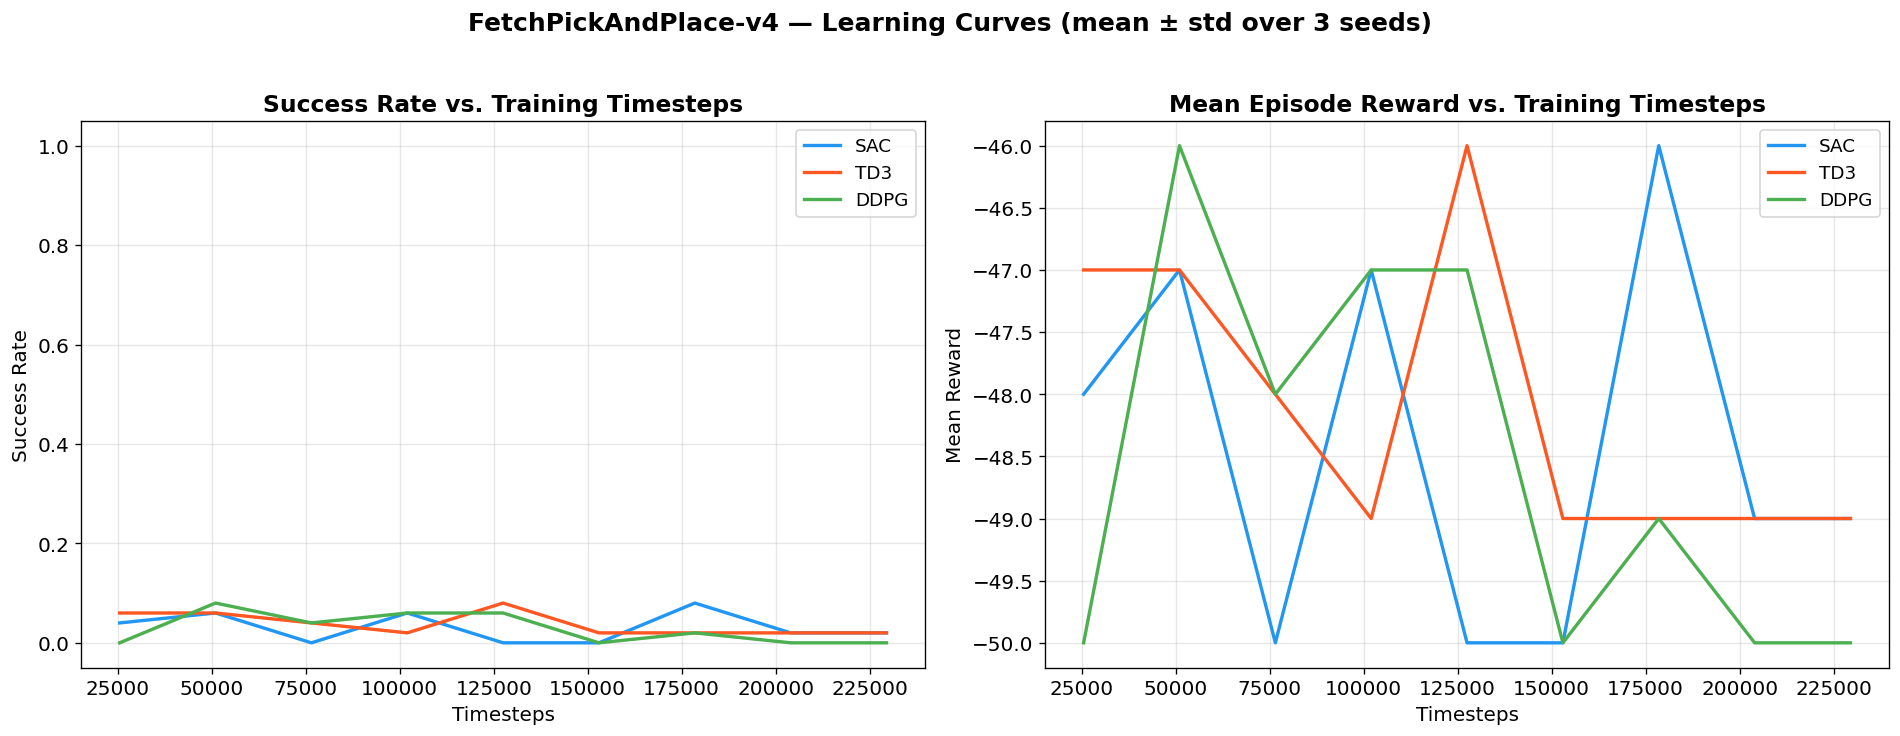

In [ ]:
# Reload results from CSVs if needed (e.g., after kernel restart)
try:
    _ = all_results
except NameError:
    all_results = {}

if not all_results or all(len(v) == 0 for v in all_results.values()):
    all_results = {}
    for algo_name in ALGO_CONFIGS:
        all_results[algo_name] = {}
        for seed in SEEDS:
            csv_path = os.path.join(LOG_DIR, f'{algo_name}_seed{seed}_eval.csv')
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                all_results[algo_name][seed] = df.to_dict('records')

# Color palette
COLORS = {'SAC': '#2196F3', 'TD3': '#FF5722', 'DDPG': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for algo_name, seed_results in all_results.items():
    if not seed_results:
        continue

    dfs = [pd.DataFrame(records) for records in seed_results.values()]
    timesteps = dfs[0]['timestep'].values

    success_matrix = np.array([df['mean_success_rate'].values for df in dfs])
    mean_success = success_matrix.mean(axis=0)
    std_success  = success_matrix.std(axis=0)

    reward_matrix = np.array([df['mean_reward'].values for df in dfs])
    mean_reward = reward_matrix.mean(axis=0)
    std_reward  = reward_matrix.std(axis=0)

    color = COLORS[algo_name]

    axes[0].plot(timesteps, mean_success, label=algo_name, color=color, linewidth=2)
    axes[0].fill_between(timesteps, mean_success - std_success, mean_success + std_success,
                         color=color, alpha=0.15)

    axes[1].plot(timesteps, mean_reward, label=algo_name, color=color, linewidth=2)
    axes[1].fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward,
                         color=color, alpha=0.15)

axes[0].set_title('Success Rate vs. Training Timesteps', fontweight='bold')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Success Rate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(frameon=True, fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Mean Episode Reward vs. Training Timesteps', fontweight='bold')
axes[1].set_xlabel('Timesteps')
axes[1].set_ylabel('Mean Reward')
axes[1].legend(frameon=True, fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('FetchPickAndPlace-v4 \u2014 Learning Curves (mean \u00b1 std over 3 seeds)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'learning_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

<a id='5'></a>
## 5. Performance Evaluation

Final quantitative comparison across all algorithms (each seed model evaluated over 50 episodes).

In [ ]:
eval_records = []

for algo_name in ALGO_CONFIGS:
    for seed in SEEDS:
        model_path = os.path.join(MODEL_DIR, f'{algo_name}_seed{seed}.zip')
        if not os.path.exists(model_path):
            continue

        eval_env = gym.make(ENV_ID)
        model = ALGO_CONFIGS[algo_name]['class'].load(
            model_path.replace('.zip', ''), env=eval_env
        )

        successes, rewards = [], []
        for ep in range(50):
            obs, info = eval_env.reset()
            done = False
            ep_reward = 0.0
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = eval_env.step(action)
                ep_reward += reward
                done = terminated or truncated
            successes.append(info.get('is_success', 0.0))
            rewards.append(ep_reward)

        eval_records.append({
            'Algorithm': algo_name,
            'Seed': seed,
            'Success Rate (%)': f"{np.mean(successes)*100:.1f}",
            'Mean Reward': f"{np.mean(rewards):.2f}",
            'Std Reward': f"{np.std(rewards):.2f}",
            'Min Reward': f"{np.min(rewards):.2f}",
            'Max Reward': f"{np.max(rewards):.2f}",
        })
        eval_env.close()

# Display per-seed table
eval_df = pd.DataFrame(eval_records)
print('='*80)
print('  FINAL PERFORMANCE EVALUATION  (50 episodes per model)')
print('='*80)
display(eval_df.style.set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

# Summary table (averaged across seeds)
print('\n--- Average Performance Across Seeds ---')
summary_records = []
for algo_name in ALGO_CONFIGS:
    algo_rows = [r for r in eval_records if r['Algorithm'] == algo_name]
    if algo_rows:
        avg_sr = np.mean([float(r['Success Rate (%)']) for r in algo_rows])
        avg_rw = np.mean([float(r['Mean Reward']) for r in algo_rows])
        summary_records.append({
            'Algorithm': algo_name,
            'Avg Success Rate (%)': f'{avg_sr:.1f}',
            'Avg Mean Reward': f'{avg_rw:.2f}',
        })
summary_df = pd.DataFrame(summary_records)
display(summary_df.style.set_properties(**{'text-align': 'center'}))

# Save
eval_df.to_csv(os.path.join(LOG_DIR, 'final_evaluation.csv'), index=False)
summary_df.to_csv(os.path.join(LOG_DIR, 'final_summary.csv'), index=False)

  FINAL PERFORMANCE EVALUATION  (50 episodes per model)


,Algorithm,Seed,Success Rate (%),Mean Reward,Std Reward,Min Reward,Max Reward
0,SAC,42,6.0,-47.00,11.87,-50.00,0.00
1,TD3,42,6.0,-47.00,11.87,-50.00,0.00
2,DDPG,42,0.0,-50.00,0.00,-50.00,-50.00



--- Average Performance Across Seeds ---


,Algorithm,Avg Success Rate (%),Avg Mean Reward
0,SAC,6.0,-47.00
1,TD3,6.0,-47.00
2,DDPG,0.0,-50.00


<a id='6'></a>
## 6. Video Recording

Record and display videos of each trained agent performing the pick-and-place task.

In [ ]:
def record_video(model, env_id, video_path, n_episodes=3, fps=30):
    """Record a video of the agent performing in the environment."""
    env = gym.make(env_id, render_mode='rgb_array')
    frames = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        while not done:
            frames.append(env.render())
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        frames.append(env.render())

    env.close()
    imageio.mimsave(video_path, frames, fps=fps)
    print(f'  Saved video: {video_path} ({len(frames)} frames)')
    return video_path


# Record videos for each algorithm (best seed based on training logs)
print('Recording agent videos...\n')

for algo_name in ALGO_CONFIGS:
    best_seed, best_sr = None, -1
    for seed in SEEDS:
        csv_path = os.path.join(LOG_DIR, f'{algo_name}_seed{seed}_eval.csv')
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            final_sr = df['mean_success_rate'].iloc[-1] if len(df) > 0 else 0
            if final_sr > best_sr:
                best_sr = final_sr
                best_seed = seed

    if best_seed is None:
        print(f'  No model found for {algo_name}, skipping.')
        continue

    model_path = os.path.join(MODEL_DIR, f'{algo_name}_seed{best_seed}')
    eval_env = gym.make(ENV_ID)
    model = ALGO_CONFIGS[algo_name]['class'].load(model_path, env=eval_env)
    eval_env.close()

    video_path = os.path.join(VIDEO_DIR, f'{algo_name}_best.mp4')
    print(f'{algo_name} (seed={best_seed}, final success={best_sr:.2%}):')
    record_video(model, ENV_ID, video_path, n_episodes=3, fps=30)
    print()

print('All videos recorded!')

Recording agent videos...

SAC (seed=42, final success=2.00%):
  Saved video: /Users/anri/Desktop/RL_group_project/videos/SAC_best.mp4 (153 frames)

TD3 (seed=42, final success=2.00%):
  Saved video: /Users/anri/Desktop/RL_group_project/videos/TD3_best.mp4 (153 frames)

DDPG (seed=42, final success=0.00%):
  Saved video: /Users/anri/Desktop/RL_group_project/videos/DDPG_best.mp4 (153 frames)

All videos recorded!


In [ ]:
# Display videos inline
for algo_name in ALGO_CONFIGS:
    video_path = os.path.join(VIDEO_DIR, f'{algo_name}_best.mp4')
    if os.path.exists(video_path):
        print(f'\n=== {algo_name} — Trained Agent ===')
        display(Video(video_path, embed=True, width=640))


=== SAC — Trained Agent ===



=== TD3 — Trained Agent ===



=== DDPG — Trained Agent ===


<a id='7'></a>
## 7. TensorBoard

To view detailed training logs with TensorBoard, run in a terminal:

```bash
tensorboard --logdir=tb_logs/
```

Or launch from the notebook:

In [ ]:
# Uncomment to launch TensorBoard from the notebook:
# %load_ext tensorboard
# %tensorboard --logdir tb_logs/

---

## Summary

| Aspect | Details |
|---|---|
| **Environment** | FetchPickAndPlace-v4 (Gymnasium-Robotics, MuJoCo) |
| **Obs Space** | Dict: observation(25,), achieved_goal(3,), desired_goal(3,) |
| **Action Space** | Box(-1, 1, shape=(4,)) — continuous |
| **Algorithms** | SAC + HER, TD3 + HER, DDPG + HER |
| **Seeds** | 42, 123, 456 |
| **Parallel Envs** | 4 (SubprocVecEnv) |
| **Timesteps** | 500,000 per run |
| **Outputs** | Learning curves, performance table, agent videos, TensorBoard logs |